# 1 · Modelos de reconstrucción: AE → DAE → híbrido → VAE

Arrancamos con **autoencoders**: se entrenan a reconstruir las campañas normales,
y lo que reconstruyen mal = anómalo. Vamos a recorrer los intentos en orden, siempre
midiendo contra el baseline IForest.

> *Nota:* esta fue la **fase de exploración**, sobre el panel original (antes de la
> limpieza de datos del NB 3). Los números absolutos suben después de limpiar; acá lo que
> importa es la **comparación relativa entre enfoques**.

In [1]:
import explib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

## 1.1 — Autoencoder (AE): búsqueda de hiperparámetros
Entrenamos **24 variantes** de AE (arquitectura, latente, dropout, schedules…).
Los 5 mejores:

In [2]:
explib.show(explib.top_runs("ae", "soja", n=5, era="dirty"))

,name,pr_auc,pr_std,roc,rec_k,n_seeds
0,ae_v23_longer,0.3773,0.0282,0.6646,0.1823,10
1,ae_v12_plateau_deep,0.3748,0.0330,0.6583,NaN,10
2,ae_v11_cosine_deep,0.3741,0.0291,0.6596,NaN,10
3,ae_v21_batch_small,0.3692,0.0149,0.6552,0.1910,10
4,ae_v18_lr_low,0.3683,0.0258,0.6567,0.1826,10


El rango de PR-AUC entre las 24 variantes fue de solo **~0.034**: tunear
hiperparámetros casi no movió la aguja → el cuello de botella no era ése. Curva de loss
y métricas del mejor AE:

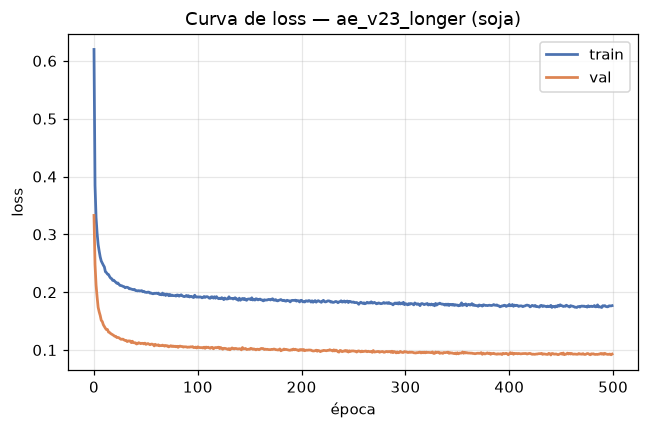

In [3]:
best_ae = explib.top_runs("ae","soja",1,era="dirty")["name"].iloc[0]
explib.plot_loss(best_ae, "soja"); plt.show()

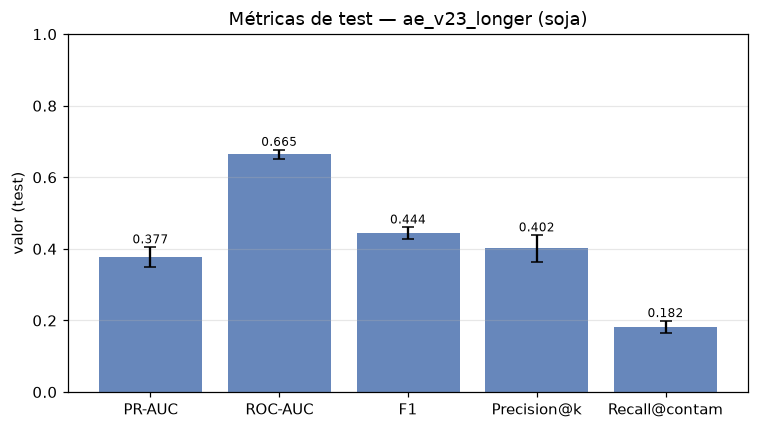

In [4]:
explib.plot_all_metrics(best_ae, "soja"); plt.show()

## 1.2 — Denoising AE (DAE)
El DAE se entrena reconstruyendo *limpio* desde un input *corrupto* → más robusto al
ruido. Ayuda un poco, pero sigue en el rango del AE.

In [5]:
explib.show(explib.compare_table([
    ("dae_v1_base","DAE base"), ("dae_v2_sweep_best","DAE sweep")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,DAE base,0.383±0.072,0.649±0.060,0.367±0.115,0.408±0.057,0.155±0.050
1,DAE sweep,0.360±0.019,0.640±0.022,0.202±0.046,0.414±0.020,0.140±0.020


## 1.3 — Híbrido: AE-latente + Isolation Forest
Idea de la literatura: correr IForest sobre el **espacio latente** del AE (no sobre las
features originales). Acá **falló** — el bottleneck del AE destruye la estructura que el
IForest necesita:

In [6]:
explib.show(explib.compare_table([("ae_iforest_v1","híbrido lat8"),
                                  ("ae_iforest_v2_latent16","híbrido lat16")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,híbrido lat8,0.271±0.071,0.506±0.077,0.339±0.042,0.264±0.092,0.129±0.063
1,híbrido lat16,0.307±0.062,0.548±0.064,0.354±0.047,0.310±0.063,0.162±0.044


## 1.4 — VAE: el salto del *score probabilístico*
El VAE no usa el MSE plano, sino `recon_prob` (An & Cho 2015): pondera el error de cada
feature **por la varianza que el decoder le asigna**. Ese cambio de *score* — no de
arquitectura — es lo que mueve la aguja.

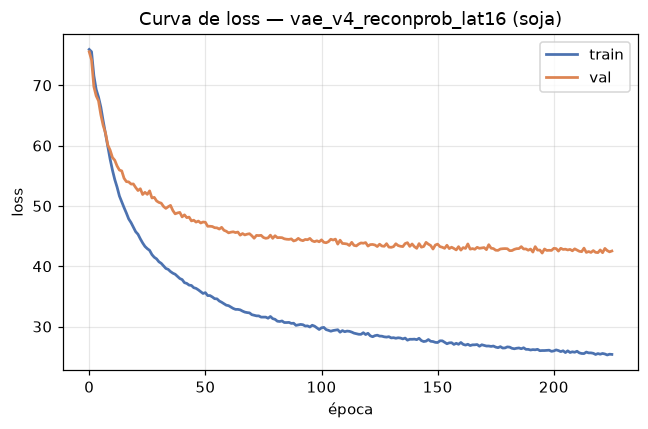

In [7]:
explib.plot_loss("vae_v4_reconprob_lat16", "soja", ); plt.show()

### Comparación de toda la fase de reconstrucción (test, media±std)
*(El DAE se exploró sobre el panel limpio (NB 3), en el mismo rango ~0.38; acá comparamos
los modelos de la misma era —panel original— para que sea justo.)*

In [8]:
explib.show(explib.compare_table([
    ("iforest_v1_base","IForest (baseline)"),
    (best_ae,"AE (mejor)"),
    ("ae_iforest_v2_latent16","Híbrido AE+IForest"),
    ("vae_v4_reconprob_lat16","VAE recon_prob"),
], "soja", era="dirty"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,IForest (baseline),0.389±0.038,0.635±0.035,0.397±0.016,0.379±0.057,0.213±0.024
1,AE (mejor),0.377±0.028,0.665±0.013,0.444±0.017,0.402±0.037,0.182±0.017
2,Híbrido AE+IForest,0.307±0.062,0.548±0.064,0.354±0.047,0.310±0.063,0.162±0.044
3,VAE recon_prob,0.435±0.031,0.667±0.029,0.414±0.023,0.434±0.045,0.237±0.022


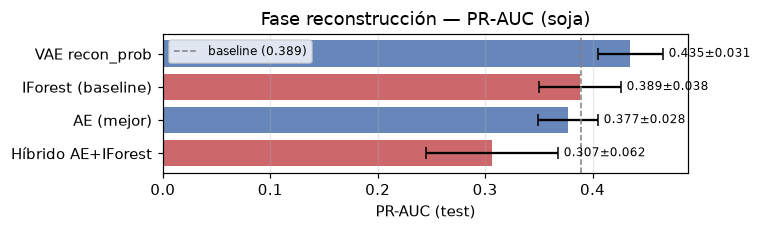

In [9]:
explib.plot_compare([
    ("iforest_v1_base","IForest (baseline)"),
    (best_ae,"AE (mejor)"),
    ("ae_iforest_v2_latent16","Híbrido AE+IForest"),
    ("vae_v4_reconprob_lat16","VAE recon_prob"),
], "soja", era="dirty", baseline=0.389, title="Fase reconstrucción — PR-AUC (soja)"); plt.show()

**Conclusión de la fase:** el **VAE con `recon_prob`** es el mejor modelo de
reconstrucción y el único que le pelea al baseline. Pero tiene un problema: **alta
varianza** (±0.03) — una sola semilla no es confiable. Eso lo atacamos en el NB 2.